# BK Sentinel — Notebook 01: Data Pipeline and Verification

**Project:** BK Sentinel — Three-Layer Dynamic Credit Risk Transition System  
**Author:** Denyse Mutoni Uwingeneye  
**Institution:** African Leadership University  

---

This notebook covers:
1. Loading the 16-month BK panel dataset
2. Exploring the data structure
3. Running BNR rule validation (Level 1)
4. Running data integrity checks (Level 2)
5. Feature engineering
6. Saving the verified ML-ready panel dataset

**Output:** `bk_sentinel_verified.csv` — used by all subsequent notebooks

## 0. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Libraries imported successfully.')

Libraries imported successfully.


## 1. Load the dataset

In [2]:
# Update this path if your file is in a different folder
DATA_PATH = 'Bk_panel_data.csv'

df = pd.read_csv(DATA_PATH, low_memory=False)

print(f'Dataset loaded successfully.')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Months covered: {sorted(df["observation_month"].unique())}')
print(f'Unique loan accounts: {df["loan_id"].nunique():,}')
print(f'Unique customers: {df["customer_id"].nunique():,}')

Dataset loaded successfully.
Shape: 67,904 rows x 32 columns
Months covered: ['2024-10', '2024-11', '2024-12', '2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12', '2026-01']
Unique loan accounts: 4,233
Unique customers: 4,173


In [3]:
# Quick look at the data
df.head()

,customer_id,loan_id,observation_month,days_in_arrears,performance_class,principal_balance,instalments_in_arrears,account_status,risk_state,branch_name,segment,loan_type,category,isic_industry_name,isic_industry_code,disbursed_amount_lcy,principal_due,accrued_interest,interest_due,penal_interest,suspended_interest,number_instalments_paid,number_instalments_outstanding,instalment_amount,interest_rate,loan_term_months,loan_repayment_frequency,disbursement_date,maturity_date,last_payment_date,date_past_due,all_crb
0,ANON_DB0EFDAE9B,LN388389,2024-10,50,SUB-STANDARD,3387291.8700,2,PAST DUE,High,NGARAMA BRANCH,RETAIL,Loan Amort&Bullet,3004.0000,Activities of households as employr,21.0000,4300000.0000,183866.6700,49398.0100,2681.3900,3677.3300,0.0000,0,60,110320.0000,17.5000,60,BUL,20240313,20290313,20260331.0000,50,3857688.0000
1,ANON_DB0EFDAE9B,LN388389,2024-11,26,WATCHLIST,3315707.3400,1,CURRENT,Medium,NGARAMA BRANCH,RETAIL,Loan Amort&Bullet,3004.0000,Activities of households as employr,21.0000,4300000.0000,95610.6700,48354.0700,1394.3200,0.0000,0.0000,0,60,110320.0000,17.5000,60,BUL,20240313,20290313,20260331.0000,26,3857688.0000
2,ANON_DB0EFDAE9B,LN388389,2024-12,5,WATCHLIST,3187976.1400,1,CURRENT,Medium,NGARAMA BRANCH,RETAIL,Loan Amort&Bullet,3004.0000,Activities of households as employr,21.0000,4300000.0000,18386.6700,46491.3200,268.1400,0.0000,0.0000,1,59,110320.0000,17.5000,60,BUL,20240313,20290313,20260331.0000,5,3857688.0000
3,ANON_DB0EFDAE9B,LN388389,2025-01,22,WATCHLIST,3119559.6900,1,CURRENT,Medium,NGARAMA BRANCH,RETAIL,Loan Amort&Bullet,3004.0000,Activities of households as employr,21.0000,4300000.0000,80901.3300,45493.5800,1179.8100,0.0000,0.0000,3,57,110320.0000,17.5000,60,BUL,20240313,20290313,20260331.0000,22,3857688.0000
4,ANON_DB0EFDAE9B,LN388389,2025-02,12,WATCHLIST,3008553.6100,2,CURRENT,Medium,NGARAMA BRANCH,RETAIL,Loan Amort&Bullet,3004.0000,Activities of households as employr,21.0000,4300000.0000,44128.0000,43874.7400,643.5300,0.0000,0.0000,2,58,110320.0000,17.5000,60,BUL,20240313,20290313,20260331.0000,12,3857688.0000


In [4]:
# Data types and null counts
print('Column info:')
print(df.dtypes)
print('\nNull counts per column:')
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0])

Column info:
customer_id                        object
loan_id                            object
observation_month                  object
days_in_arrears                     int64
performance_class                  object
principal_balance                 float64
instalments_in_arrears              int64
account_status                     object
risk_state                         object
branch_name                        object
segment                            object
loan_type                          object
category                          float64
isic_industry_name                 object
isic_industry_code                float64
disbursed_amount_lcy              float64
principal_due                     float64
accrued_interest                  float64
interest_due                      float64
penal_interest                    float64
suspended_interest                float64
number_instalments_paid             int64
number_instalments_outstanding      int64
instalment_amount    

## 2. Level 1 — BNR Rule Validation

Every risk state must be consistent with BNR prudential classification rules:
- DPD = 0 → Low (Standard)
- DPD 1–30 → Medium (Watchlist)
- DPD 31–90 → High (Sub-Standard / Doubtful)
- DPD > 90 → Default (Loss)

In [5]:
print('=' * 60)
print('LEVEL 1: BNR RULE VALIDATION')
print('=' * 60)

violations = {}

# Check 1: DPD = 0 must be Low
v1 = df[(df['days_in_arrears'] == 0) & (df['risk_state'] != 'Low')]
violations['DPD=0 but risk_state != Low'] = len(v1)

# Check 2: DPD 1-30 must be Medium
v2 = df[(df['days_in_arrears'] >= 1) & (df['days_in_arrears'] <= 30) & (df['risk_state'] != 'Medium')]
violations['DPD 1-30 but risk_state != Medium'] = len(v2)

# Check 3: DPD 31-90 must be High
v3 = df[(df['days_in_arrears'] >= 31) & (df['days_in_arrears'] <= 90) & (df['risk_state'] != 'High')]
violations['DPD 31-90 but risk_state != High'] = len(v3)

# Check 4: DPD > 90 must be Default
v4 = df[(df['days_in_arrears'] > 90) & (df['risk_state'] != 'Default')]
violations['DPD > 90 but risk_state != Default'] = len(v4)

# Check 5: Suspended interest must only exist when DPD > 90
v5 = df[(df['suspended_interest'] > 0) & (df['days_in_arrears'] < 90)]
violations['suspended_interest > 0 but DPD < 90'] = len(v5)

all_passed = True
for check, count in violations.items():
    status = 'PASS' if count == 0 else f'FLAG — {count:,} records'
    if count > 0:
        all_passed = False
    print(f'  {check}: {status}')

print()
if all_passed:
    print('Level 1 PASSED. All BNR rules are consistent.')
else:
    print('Level 1 has FLAGS. Review before proceeding.')

LEVEL 1: BNR RULE VALIDATION
  DPD=0 but risk_state != Low: PASS
  DPD 1-30 but risk_state != Medium: PASS
  DPD 31-90 but risk_state != High: PASS
  DPD > 90 but risk_state != Default: PASS
  suspended_interest > 0 but DPD < 90: PASS

Level 1 PASSED. All BNR rules are consistent.


## 3. Level 2 — Data Integrity Checks

In [6]:
print('=' * 60)
print('LEVEL 2: DATA INTEGRITY CHECKS')
print('=' * 60)

# Check 1: Duplicate loan_id within same observation_month
dupes = df.duplicated(subset=['loan_id', 'observation_month']).sum()
print(f'\nDuplicate loan_id + observation_month pairs: {dupes} (expected: 0)')

# Check 2: Negative days in arrears
neg_dpd = (df['days_in_arrears'] < 0).sum()
print(f'Negative days_in_arrears: {neg_dpd} (expected: 0)')

# Check 3: Interest rate range
bad_ir = df[(df['interest_rate'] < 0) | (df['interest_rate'] > 50)]
print(f'Interest rate outside 0-50%: {len(bad_ir)} (expected: 0)')

# Check 4: Loan term range
bad_lt = df[(df['loan_term_months'] < 1) | (df['loan_term_months'] > 360)]
print(f'Loan term outside 1-360 months: {len(bad_lt)} (expected: 0)')

# Check 5: Panel continuity — how many loan_ids appear in all 16 months
months_per_loan = df.groupby('loan_id')['observation_month'].nunique()
full_panel = (months_per_loan == 16).sum()
partial_panel = (months_per_loan < 16).sum()
print(f'\nLoan accounts present in all 16 months: {full_panel:,}')
print(f'Loan accounts present in fewer than 16 months: {partial_panel:,}')

# Check 6: Segment coverage
print(f'\nSegment distribution:')
seg = df.drop_duplicates('loan_id')['segment'].value_counts()
for s, c in seg.items():
    print(f'  {s}: {c:,}')

LEVEL 2: DATA INTEGRITY CHECKS

Duplicate loan_id + observation_month pairs: 176 (expected: 0)
Negative days_in_arrears: 0 (expected: 0)
Interest rate outside 0-50%: 23472 (expected: 0)
Loan term outside 1-360 months: 0 (expected: 0)

Loan accounts present in all 16 months: 4,233
Loan accounts present in fewer than 16 months: 0

Segment distribution:
  RETAIL: 3,771
  SME: 194
  AGRICULTURE: 65
  CORPORATE: 31
  Institutional Banking: 3


## 4. Null value handling

In [7]:
# Drop records with null in critical columns only
critical_cols = ['customer_id', 'loan_id', 'observation_month',
                 'days_in_arrears', 'risk_state', 'performance_class']

before = len(df)
df_clean = df.dropna(subset=critical_cols).copy()
after = len(df_clean)

print(f'Records before cleaning: {before:,}')
print(f'Records after removing critical nulls: {after:,}')
print(f'Records removed: {before - after:,}')

# Fill non-critical nulls
df_clean['segment'] = df_clean['segment'].fillna('UNKNOWN')
df_clean['isic_industry_name'] = df_clean['isic_industry_name'].fillna('UNKNOWN')
df_clean['penal_interest'] = df_clean['penal_interest'].fillna(0)
df_clean['suspended_interest'] = df_clean['suspended_interest'].fillna(0)
df_clean['principal_due'] = df_clean['principal_due'].fillna(0)
df_clean['accrued_interest'] = df_clean['accrued_interest'].fillna(0)
df_clean['interest_due'] = df_clean['interest_due'].fillna(0)

print('\nNon-critical nulls filled.')
print(f'Remaining nulls: {df_clean.isnull().sum().sum()}')

Records before cleaning: 67,904
Records after removing critical nulls: 67,888
Records removed: 16

Non-critical nulls filled.
Remaining nulls: 23888


## 5. Feature Engineering

In [8]:
# Encode risk_state as numeric for ML models
# Low=0, Medium=1, High=2, Default=3
risk_map = {'Low': 0, 'Medium': 1, 'High': 2, 'Default': 3}
df_clean['risk_state_code'] = df_clean['risk_state'].map(risk_map)

print('risk_state_code distribution:')
print(df_clean['risk_state_code'].value_counts().sort_index())

risk_state_code distribution:
risk_state_code
0    45946
1     9768
2     4800
3     7374
Name: count, dtype: int64


In [9]:
# Sort by loan_id and observation_month for panel operations
df_clean = df_clean.sort_values(['loan_id', 'observation_month']).reset_index(drop=True)

# Engineer: repayment_ratio
# Ratio of principal paid to total disbursed amount
# 1.0 = fully paid, 0.0 = nothing paid
df_clean['repayment_ratio'] = np.where(
    df_clean['disbursed_amount_lcy'] > 0,
    1 - (df_clean['principal_balance'] / df_clean['disbursed_amount_lcy']),
    0
).clip(0, 1)

# Engineer: loan_age_months (how many months since disbursement)
df_clean['disbursement_date'] = pd.to_datetime(
    df_clean['disbursement_date'].astype(str).str[:8], format='%Y%m%d', errors='coerce')
df_clean['obs_date'] = pd.to_datetime(df_clean['observation_month'], format='%Y-%m')
df_clean['loan_age_months'] = (
    (df_clean['obs_date'].dt.year - df_clean['disbursement_date'].dt.year) * 12 +
    (df_clean['obs_date'].dt.month - df_clean['disbursement_date'].dt.month)
).clip(lower=0)

# Engineer: arrears_ratio
df_clean['arrears_ratio'] = np.where(
    df_clean['loan_term_months'] > 0,
    df_clean['instalments_in_arrears'] / df_clean['loan_term_months'],
    0
).clip(0, 1)

# Engineer: next_risk_state — the target for ML (what happens next month)
df_clean['next_risk_state'] = df_clean.groupby('loan_id')['risk_state'].shift(-1)
df_clean['next_risk_state_code'] = df_clean.groupby('loan_id')['risk_state_code'].shift(-1)

print('Features engineered:')
print('  repayment_ratio — how much of the loan has been repaid')
print('  loan_age_months — how old the loan is at each observation')
print('  arrears_ratio — instalments_in_arrears / loan_term_months')
print('  next_risk_state — target variable for Layer 1 ML')
print(f'\nRecords with a valid next_risk_state: {df_clean["next_risk_state"].notna().sum():,}')
print(f'Records without (last month per loan): {df_clean["next_risk_state"].isna().sum():,}')

Features engineered:
  repayment_ratio — how much of the loan has been repaid
  loan_age_months — how old the loan is at each observation
  arrears_ratio — instalments_in_arrears / loan_term_months
  next_risk_state — target variable for Layer 1 ML

Records with a valid next_risk_state: 63,656
Records without (last month per loan): 4,232


## 6. Exploratory Data Analysis

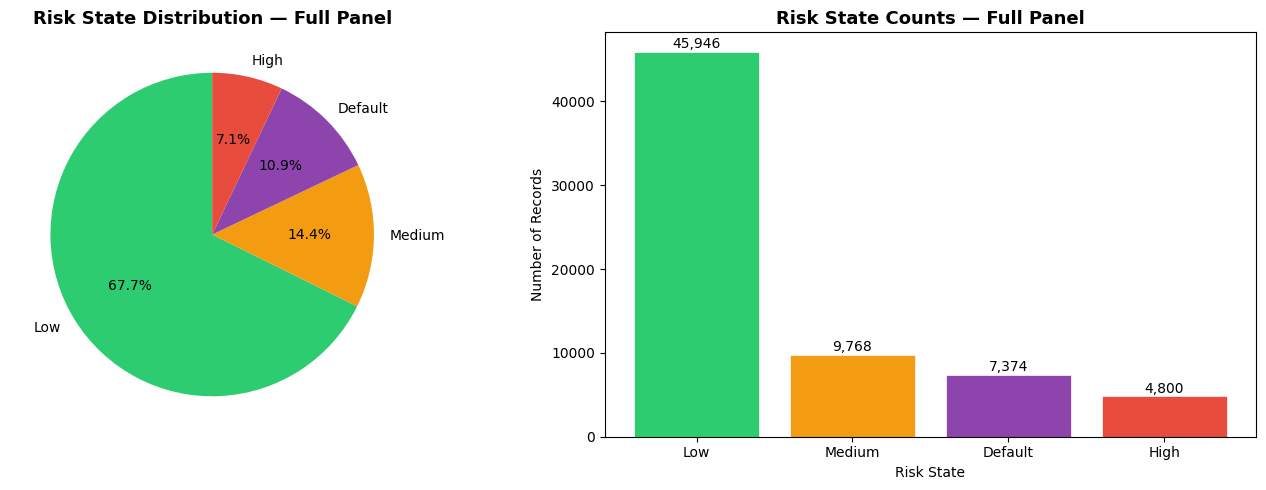

Chart saved.


In [10]:
# Risk state distribution
colors = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c', 'Default': '#8e44ad'}
state_counts = df_clean['risk_state'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
axes[0].pie(
    state_counts.values,
    labels=state_counts.index,
    autopct='%1.1f%%',
    colors=[colors[s] for s in state_counts.index],
    startangle=90
)
axes[0].set_title('Risk State Distribution — Full Panel', fontsize=13, fontweight='bold')

# Bar chart with counts
bars = axes[1].bar(
    state_counts.index,
    state_counts.values,
    color=[colors[s] for s in state_counts.index],
    edgecolor='white', linewidth=0.5
)
axes[1].set_title('Risk State Counts — Full Panel', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Risk State')
axes[1].set_ylabel('Number of Records')
for bar, count in zip(bars, state_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{count:,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('01_risk_state_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')

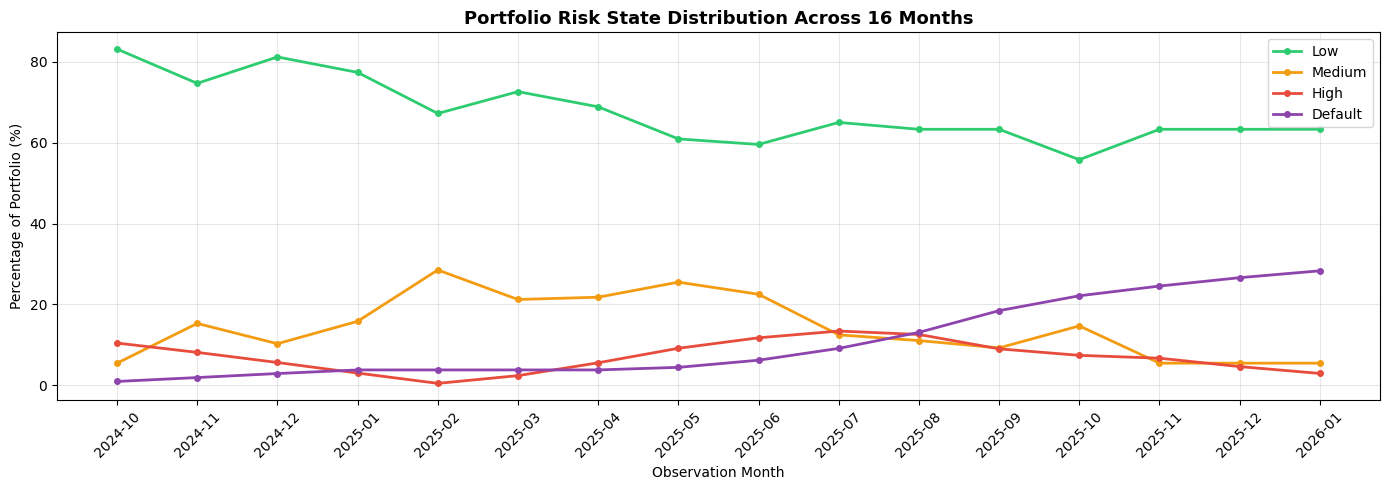

Chart saved.


In [11]:
# Risk state distribution over time — how the portfolio evolves month by month
monthly = df_clean.groupby(['observation_month', 'risk_state']).size().unstack(fill_value=0)
monthly_pct = monthly.div(monthly.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 5))
for state in ['Low', 'Medium', 'High', 'Default']:
    if state in monthly_pct.columns:
        ax.plot(monthly_pct.index, monthly_pct[state],
                marker='o', markersize=4, label=state, color=colors[state], linewidth=2)

ax.set_title('Portfolio Risk State Distribution Across 16 Months', fontsize=13, fontweight='bold')
ax.set_xlabel('Observation Month')
ax.set_ylabel('Percentage of Portfolio (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('01_risk_evolution_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')

In [12]:
# Class imbalance summary
print('=' * 60)
print('CLASS IMBALANCE SUMMARY')
print('=' * 60)
total = len(df_clean)
for state in ['Low', 'Medium', 'High', 'Default']:
    count = (df_clean['risk_state'] == state).sum()
    pct = count / total * 100
    bar = '█' * int(pct / 2)
    print(f'  {state:<10} {count:>8,}  ({pct:5.1f}%)  {bar}')
print(f'  {"TOTAL":<10} {total:>8,}')
print()
print('Note: SMOTE and class-weighted models will handle this imbalance in Notebook 02.')

CLASS IMBALANCE SUMMARY
  Low          45,946  ( 67.7%)  █████████████████████████████████
  Medium        9,768  ( 14.4%)  ███████
  High          4,800  (  7.1%)  ███
  Default       7,374  ( 10.9%)  █████
  TOTAL        67,888

Note: SMOTE and class-weighted models will handle this imbalance in Notebook 02.


## 7. Level 3 — Transition Matrix Preview

Quick verification of the panel structure by computing the transition matrix from all 15 consecutive monthly pairs.

In [13]:
# Use only rows that have a valid next_risk_state (i.e. not the last month)
df_transitions = df_clean.dropna(subset=['next_risk_state']).copy()

states = ['Low', 'Medium', 'High', 'Default']

# Count transitions
transition_counts = pd.crosstab(
    df_transitions['risk_state'],
    df_transitions['next_risk_state'],
    rownames=['From'],
    colnames=['To']
)
transition_counts = transition_counts.reindex(index=states, columns=states, fill_value=0)

# Convert to probabilities
transition_matrix = transition_counts.div(transition_counts.sum(axis=1), axis=0)

print('Empirical Monthly Transition Matrix:')
print(transition_matrix.round(4))

print('\nRow sums (must all be 1.000):')
row_sums = transition_matrix.sum(axis=1).round(4)
print(row_sums)

# Verification
if all(abs(row_sums - 1.0) < 0.001):
    print('\nLevel 3 PASSED. All row sums equal 1.000.')
else:
    print('\nLevel 3 FLAG. Some rows do not sum to 1.000.')

print(f'\nTotal transition pairs used: {len(df_transitions):,}')
print(f'Default self-transition probability: {transition_matrix.loc["Default", "Default"]:.4f}')

Empirical Monthly Transition Matrix:
To         Low  Medium   High  Default
From                                  
Low     0.9406  0.0537 0.0029   0.0029
Medium  0.1812  0.7088 0.1091   0.0009
High    0.0000  0.0954 0.6822   0.2224
Default 0.0008  0.0015 0.0005   0.9972

Row sums (must all be 1.000):
From
Low       1.0000
Medium    1.0000
High      1.0000
Default   1.0000
dtype: float64

Level 3 PASSED. All row sums equal 1.000.

Total transition pairs used: 63,656
Default self-transition probability: 0.9972


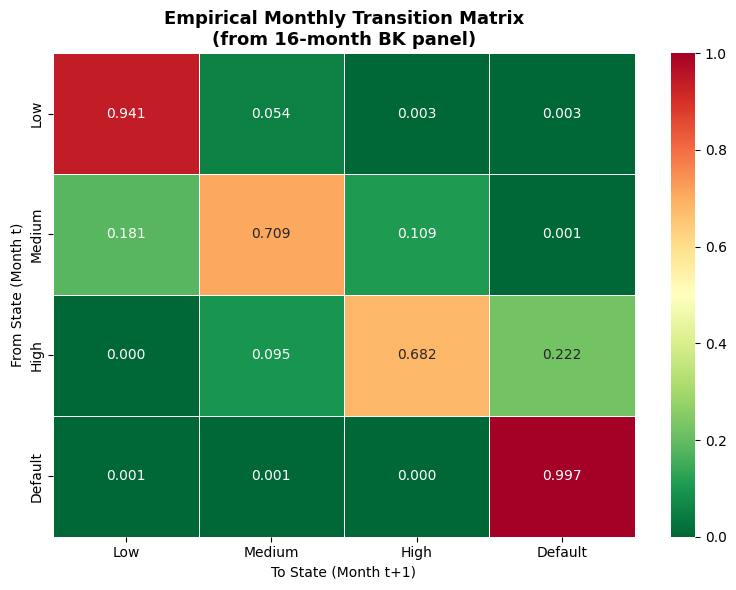

Transition matrix heatmap saved.


In [14]:
# Visualise the transition matrix as a heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    transition_matrix,
    annot=True, fmt='.3f',
    cmap='RdYlGn_r',
    vmin=0, vmax=1,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Empirical Monthly Transition Matrix\n(from 16-month BK panel)', fontsize=13, fontweight='bold')
ax.set_xlabel('To State (Month t+1)')
ax.set_ylabel('From State (Month t)')
plt.tight_layout()
plt.savefig('01_transition_matrix_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Transition matrix heatmap saved.')

## 8. Save verified dataset

In [15]:
# Save the full cleaned panel — used by all subsequent notebooks
df_clean.to_csv('bk_sentinel_verified.csv', index=False)

# Also save just the transition pairs for Layer 2
df_transitions.to_csv('bk_sentinel_transitions.csv', index=False)

# Save the transition matrix
transition_matrix.to_csv('bk_transition_matrix.csv')
transition_counts.to_csv('bk_transition_counts.csv')

print('Files saved:')
print(f'  bk_sentinel_verified.csv   — {len(df_clean):,} rows (full cleaned panel)')
print(f'  bk_sentinel_transitions.csv — {len(df_transitions):,} rows (rows with next_risk_state)')
print(f'  bk_transition_matrix.csv   — empirical monthly transition probabilities')
print(f'  bk_transition_counts.csv   — raw transition counts')

Files saved:
  bk_sentinel_verified.csv   — 67,888 rows (full cleaned panel)
  bk_sentinel_transitions.csv — 63,656 rows (rows with next_risk_state)
  bk_transition_matrix.csv   — empirical monthly transition probabilities
  bk_transition_counts.csv   — raw transition counts


## 9. Summary

In [16]:
print('=' * 60)
print('NOTEBOOK 01 COMPLETE — SUMMARY')
print('=' * 60)
print(f'Total records loaded:          {len(df):,}')
print(f'Records after cleaning:        {len(df_clean):,}')
print(f'Observation months:            {df_clean["observation_month"].nunique()}')
print(f'Unique loan accounts:          {df_clean["loan_id"].nunique():,}')
print(f'Unique customers:              {df_clean["customer_id"].nunique():,}')
print(f'Transition pairs for Markov:   {len(df_transitions):,}')
print(f'Features engineered:           repayment_ratio, loan_age_months, arrears_ratio')
print(f'Target variable created:       next_risk_state (for Layer 1 ML)')
print()
print('Risk state distribution:')
for state in ['Low', 'Medium', 'High', 'Default']:
    count = (df_clean['risk_state'] == state).sum()
    pct = count / len(df_clean) * 100
    print(f'  {state:<10} {count:>8,}  ({pct:.1f}%)')
print()
print('Key finding:')
print(f'  Default self-transition probability: {transition_matrix.loc["Default", "Default"]:.4f}')
print(f'  -> Default is near-absorbing (criterion: >= 0.95)')
print()
print('Next: Run Notebook 02 — Layer 1 Classification (Random Forest and XGBoost)')

NOTEBOOK 01 COMPLETE — SUMMARY
Total records loaded:          67,904
Records after cleaning:        67,888
Observation months:            16
Unique loan accounts:          4,232
Unique customers:              4,173
Transition pairs for Markov:   63,656
Features engineered:           repayment_ratio, loan_age_months, arrears_ratio
Target variable created:       next_risk_state (for Layer 1 ML)

Risk state distribution:
  Low          45,946  (67.7%)
  Medium        9,768  (14.4%)
  High          4,800  (7.1%)
  Default       7,374  (10.9%)

Key finding:
  Default self-transition probability: 0.9972
  -> Default is near-absorbing (criterion: >= 0.95)

Next: Run Notebook 02 — Layer 1 Classification (Random Forest and XGBoost)
